<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/11_the-beauty-of-knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 11: The beauty of kNN

In this exercise, you'll gain practice working with kNN. We'll use the [diamonds](https://ggplot2.tidyverse.org/reference/diamonds.html) dataset, which comes as part of `ggplot2`. This dataset provides information on the quality and price of 50,000 diamonds


## 1. Data, Plotting, and Train/Test Sets (2 pts)
-----
* Load the the `class` and `tidyverse` packages.
* Assign the `diamonds` data set to a simpler name. Then, create a new variable `price_bin` that splits the `price` variable into a binary variable, where 1 indicates that the diamond costs greater than the mean price, and 0 indicates that the diamond costs less than the mean price. Set `price_bin` to be a factor. (*Hint: use the if_else() function*)
* Select just the `carat`, `depth`, `table`, `x`, `y`, and your new `price_bin` variables
* Print the first few lines of the data set
* Print the dimensions of the data set


In [2]:
# Load packages
library(class)
library(tidyverse)

# Assign diamonds to a simpler name and create price_bin
df <- diamonds %>%
  mutate(price_bin = as.factor(if_else(price > mean(price), 1, 0))) %>%
  select(carat, depth, table, x, y, price_bin)

# Print first few lines
head(df)

# Print dimensions
dim(df)

carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
0.23,61.5,55,3.95,3.98,0
0.21,59.8,61,3.89,3.84,0
0.23,56.9,65,4.05,4.07,0
0.29,62.4,58,4.20,4.23,0
0.31,63.3,58,4.34,4.35,0
0.24,62.8,57,3.94,3.96,0


[1] 53940     6

### Plot
Create a scatterplot of the link between `carat` and `depth`, and use the `color` aesthetics mapping to differentiate between diamonds that cost above versus below the mean price.

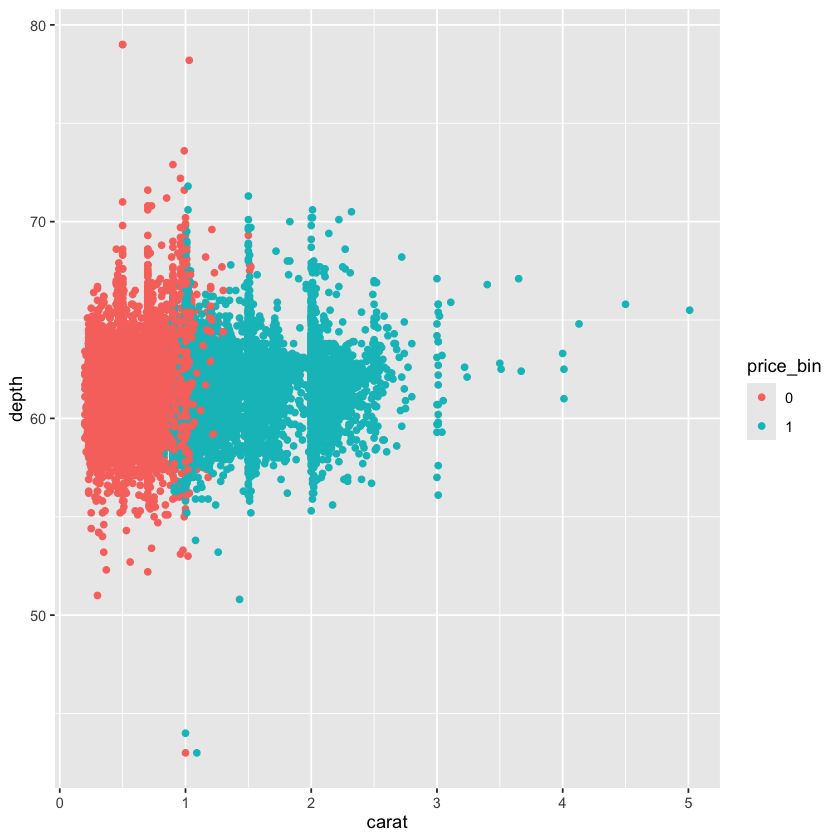

In [3]:
ggplot(df, aes(x = carat, y = depth, color = price_bin)) +
  geom_point()

Based on the above scatterplot, how do you think kNN will perform using only these two variables to predict diabetes diagnosis? Which variable, carat or depth, gives us the most information about which price class the diamond will belong to?
> * Based on the scatterplot above, I think kNN would perform reasonably well using the two variables. This is becasue we can see that the carat provides a pretty clear seperation between the two price classes. From the plot, diamonds below the main price (0, in red) are clustered at lower carat values (approximately 0-1) while the diamonds above the mean price (1, in blue) tend to have higher carat values (roughly above 1). Although there are some overlap in the middle, the two groups are still pretty distinguishable along the carat axis.
>
> * Therefore, I think carat gives us the most information about which price class the dimaond will belong to. This is because, as mentioned above, there is a clear horizontal separation between the two groups along the carat axis. In contrast, depth does not meaningfully differentiate between the two classes. We can see that both groups span roughly the same range of depth values (roughly 55-70 for most points), and they almost entirely overlap among the two groups. This indicates that depth contributes very little discriminatory poweer for predicting price class, while carat is the primary divider of this classification.

### Test vs Train

Before we run KNN on these data, we need to set aside a portion of the observations as our test set. Below, randomly divide the data such that 30% are allotted to the `test` set and the rest are allotted to the `train` set. Print the first few lines of each set, and print the dimensions of each set to double check your division of the data.

In [4]:
set.seed(2023)

# Pull random sample of 30% of row indices for test set
test.inds <- sample(1:nrow(df), round(0.3 * nrow(df)))

# Split into train and test sets
train <- df[-test.inds, ]
test <- df[test.inds, ]

# Print first few lines of each set
head(train)
head(test)

# Print dimensions of each set
dim(train)
dim(test)

carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
0.23,61.5,55,3.95,3.98,0
0.23,56.9,65,4.05,4.07,0
0.29,62.4,58,4.20,4.23,0
0.31,63.3,58,4.34,4.35,0
0.24,62.8,57,3.94,3.96,0
0.24,62.3,57,3.95,3.98,0


carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1.22,62.3,56.0,6.81,6.84,1
1.57,62.3,56.0,7.48,7.41,1
1.11,62.4,57.7,6.57,6.64,1
0.42,60.6,57.0,4.82,4.85,0
0.32,62.6,55.0,4.39,4.36,0
0.90,62.7,58.0,6.06,6.15,1


[1] 37758     6

[1] 16182     6

## 2: KNN (3 points)
----
Now, use the `knn()` function from the `class` library to predict `price_bin` from the `carat` and `depth`. Set `k = 3`.

*Hint: Review the format required for the arguments of knn()*

In [6]:
set.seed(2023)

# Set up training predictors and labels
train.preds <- cbind(train$carat, train$depth)
train.labels <- train$price_bin

# Set up test predictors
test.preds <- cbind(test$carat, test$depth)

# Run kNN with k = 3
test.knn <- knn(train.preds, test.preds, train.labels, k = 3)

#print first 10 test specifications
test.knn[1:10]

[1] 1 1 1 0 0 1 1 0 0 0
Levels: 0 1

Now, output a confusion matrix and calculate the test error to evaluate model performance.

In [8]:
# Confusion matrix
confusion_df <- data.frame(predicted = test.knn, actual = test$price_bin)
table(confusion_df)
print("---")
print(paste("Test Error:", mean(confusion_df$predicted != confusion_df$actual)))

         actual
predicted    0    1
        0 9707  316
        1  539 5620

[1] "---"
[1] "Test Error: 0.0528364849833148"


How did your model perform?
> * The model performed pretty well, with only a test error of approximately 5.3%, which would mean that it correctly classified about 94.7% of diamonds into the right price category. Looking specifically at the confusion matrix, the model predicted 9707 diamonds correctly as below mean price and 5620 correctly as above mean price. It made relatively fewer errors: 316 diamonds were falsely predicted as below mean price when they were truely above, and 539 were falsely predicted as wabove mean average price when they were actually below. Thus, the model seems to be slightly better at identifying diamonds below the mean price than above it. However, the overall error rate is still pretty low.


Let's try to improve our model by adding all of the other variables in our data set as predictors. Rerun your `knn()` below, keeping `k = 3`. Again, output a confusion matrix and error rate for your updated model fit.

In [9]:
set.seed(2023)

# Set up training predictors with all variables (carat, depth, table, x, y)
train.preds.all <- cbind(train$carat, train$depth, train$table, train$x, train$y)
train.labels <- train$price_bin

# Set up test predictors with all variables
test.preds.all <- cbind(test$carat, test$depth, test$table, test$x, test$y)

# Run kNN with k = 3
test.knn.all <- knn(train.preds.all, test.preds.all, train.labels, k = 3)

# Confusion matrix
confusion_df_all <- data.frame(predicted = test.knn.all, actual = test$price_bin)
table(confusion_df_all)
print("---")
print(paste("Test Error:", mean(confusion_df_all$predicted != confusion_df_all$actual)))

         actual
predicted    0    1
        0 9728  391
        1  518 5545

[1] "---"
[1] "Test Error: 0.0561735261401557"


Did your model predictions improve?
> * Surprisingly no. The model prediction did not improve. In fact, the test error even slightly increased from approximately 5.28% to 5.62% when adding the additional variables. In the confusion matrix, we can see that the results are pretty similar to the previous model: true negatives went up slightly (9728 vs 9707), but false negatives also increased (391 vs 316), which indicates that more above mean price diamonds were incorrectly classified as below mean. The overall performance got marginally worse. Thus, the addition of extra vriables may not proovide much useful information for distinguishing price classes, and may instead introduced some noise that makes it harder for kNN to find the correct nearest neighbors.


# 3: for loop (3 points)
----

So adding additional predictors didn't shift our error much. Let's see if adjusting `k` has a larger impact on model accuracy.

Using your initial model above with just `carat` and `depth`, run a `for loop` that runs the same model 30 times, for `k = 1:30`.

Output a data frame that has `k` and the overall `error` as columns.

The structure of the output data frame and `for loop` are provided for you below. Note that your loop will take a minute or two to run because there are so many observations in the dataset. It may be helpful while you are writing and testing your loop to run it on a subset of the data with only a handful of rows.

In [10]:
# this is provided
# setting up empty table to store for loop output
output  <- data.frame(k = seq(1:30),
                     error = rep(NA, 30))
head(output)

,k,error
,<int>,<lgl>
1,1,NA
2,2,NA
3,3,NA
4,4,NA
5,5,NA
6,6,NA


In [12]:
set.seed(2023)

for (k in seq(1:30)) {
    knn_fits <- knn(train.preds, test.preds, train.labels, k = k)

    # Overall error
    conf_df <- data.frame(predicted = knn_fits, actual = test$price_bin)
    output$error[k] <- mean(conf_df$predicted != conf_df$actual)
}
head(output)

,k,error
,<int>,<dbl>
1,1,0.05363985
2,2,0.05333086
3,3,0.05413422
4,4,0.05326906
5,5,0.05258930
6,6,0.05265109


Create a line plot of your `output` object using `ggplot`. Add a (non-linear) `geom_smooth` layer.

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


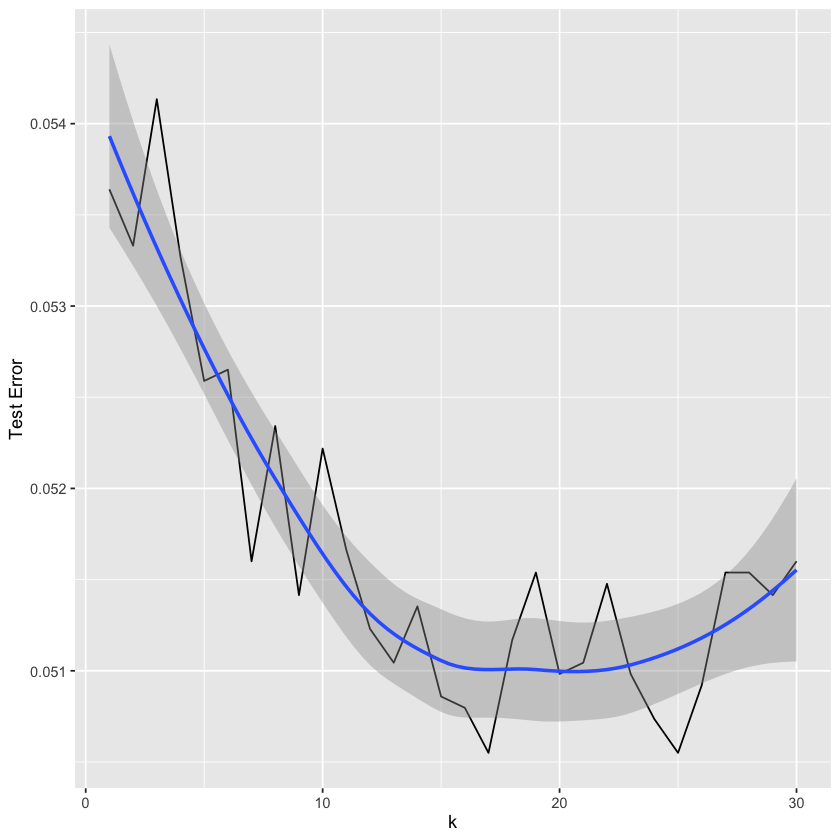

In [16]:
ggplot(output, aes(x = k, y = error)) +
  geom_line() +
  geom_smooth() +
  labs(x = "k", y = "Test Error")

Interpret your plot. What would you select as the best value of `k`? How much does this improve your test error?
> * The plot shows that test error follows a pattern that generally decreases as k increases from 1 to around 15-20, then after whioch it starts to increase again. Some k value (s) seems to exist either global or local minimums for the test error values. Based on the smooth trend line, the optimal k would be around k = 17-20 (I would use k = 18), where the test error reaches its lowest point at aproximately 0.051. Beyond this range, the error begins to creep back up as the k increases or decreases. Compared to our initial model with k = 3 (test error approximately 0.0528), the best k improves the test error to roughly 0.051. This is a pretty modest improvement of about 0.18 percentage points. But though the improvement is not too dramatic, this is still a good improvement given that the model was already performing well. And a bigger improvement compared to our later model with more variables added (0.5 percentage point improvement).


# 4: Standardizing predictors (2)
-----

Because knn is based on distances between points, it is very sensitive to the scale of your variables. Looking at our predictor variables, we can see that `carat` and `depth` are orders of magnitude different in terms of scales. Maybe we can improve our fit even more by addressing this!

Below, use the `scale()` function to standardize your predictors. (Note that you don't need to standardize `price_bin`.)

Then, run your model a final time with your standardized predictors (just `carat` and `depth` still). Set `k` to the optimal value you determined in your plot above. Output the confusion matrix and error rate again.

In [17]:
set.seed(2023)

# Standardize predictors in train and test sets
train.preds.scaled <- cbind(scale(train$carat), scale(train$depth))
test.preds.scaled <- cbind(scale(test$carat), scale(test$depth))

# Run kNN with optimal k
knn_fits_scaled <- knn(train.preds.scaled, test.preds.scaled, train.labels, k = 18)

# Confusion matrix
confusion_df_scaled <- data.frame(predicted = knn_fits_scaled, actual = test$price_bin)
table(confusion_df_scaled)
print("---")
print(paste("Test Error:", mean(confusion_df_scaled$predicted != confusion_df_scaled$actual)))

         actual
predicted    0    1
        0 9712  285
        1  534 5651

[1] "---"
[1] "Test Error: 0.0506117908787542"


What impact did rescaling the data have on your error rate?
> * Compared with the plot above when k = 18, standardizing the predictors slightly improved the error rate. The test error decreased from approximately 0.051 to 0.0506. But since the error rate of 0.051 was eyeballed, I am not exactly sure whether this improvement actually existed. So I would assume that there still exist a small improvement, showing that rescaling did have a minor positive effect on error rate. Overall, comparing all our models, the origional model (k = 3, unscaled) had a test error of 0.0528, tuning k to 18 brought it down to approximately 0.051, and adding standardization further reduced it to 0.0506. Each step provided incremental improvement to the error rate. The gain seemed small, but I think is due to the fact that the model is already performing near ceiling for this task.


**DUE:** 5pm March 17, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*
>
>
